In [3]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
import pandas as pd
from matplotlib import pyplot as plt
import numpy as np
from scipy import stats
import seaborn as sns

# oldies but goldies

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f81c41201d0>]],
      dtype=object)

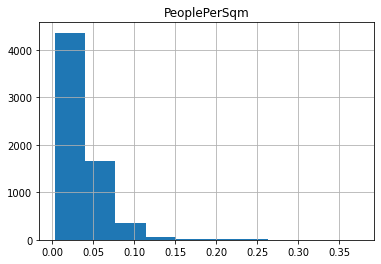

In [117]:
#@title outlier with IQR01
def outliers(s, replace=np.nan):
    '''
    https://stackoverflow.com/questions/55268364/how-to-replace-outliers-with-median-in-pandas-dataframe
    https://stackoverflow.com/questions/68258648/find-and-replace-outliers-with-nan-in-python
    '''
    median = s.median()
    Q1, Q3 = np.percentile(s, [25 ,75])
    IQR = Q3-Q1
    s.where((s < (Q1 - 1.5 * IQR)) | (s > (Q3 + 1.5 * IQR)), replace)
    s.fillna(median, inplace=True) #replace with median value
    return s.hist()
    
outliers(dfTUIK) #to_csv('outliers.csv')

In [ ]:
#@title OccUniformRandomInteger { form-width: "10%" }
from scipy.stats import randint
import numpy as np
import matplotlib.pyplot as plt

#fig, ax = plt.subplots(1, 1)

low, high = 1, 7 #TUIK
mean, var, skew, kurt = randint.stats(low, high, 
                                      #moments='mvsk'
                                      )

x = np.arange(randint.ppf(0.01, low, high),
              randint.ppf(0.99, low, high))
print(x)
'''
ax.plot(x, randint.pmf(x, low, high), 'bo', ms=8, label='randint pmf')
ax.vlines(x, 0, randint.pmf(x, low, high), colors='b', lw=5, alpha=0.5)

rv = randint(low, high)
ax.vlines(x, 0, rv.pmf(x), colors='k', linestyles='-', lw=1,
        label='frozen pmf')

ax.legend(loc='right', frameon=True)
plt.show()
'''

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f81c75e8950>]],
      dtype=object)

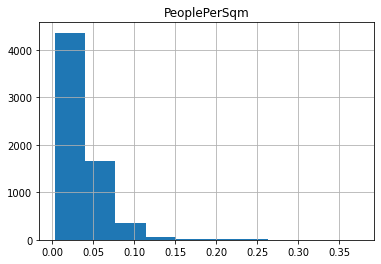

In [75]:
#@title outlier with IQR
# method 1.
df = dfTUIK
Q1 = np.percentile(df , 25)
Q3 = np.percentile(df , 75)
# method 2.
Q1,Q3 = np.percentile(df , [25,75])

IQR = Q3 - Q1
ul = Q3+1.5*IQR
ll = Q1-1.5*IQR

median = df.median()
#outliers = df[(df > ul) | (df < ll)]
outliers = df[(df > ul) & (df < ll)]
outliers
#df[outliers] = np.nan
#df.fillna(median, inplace=True)
#df_out = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR)))]
df_out = df[~((df < (Q1 - 1.5 * IQR)) & (df > (Q3 + 1.5 * IQR)))]
#df_sout = ((df < (Q1 - 1.5 * IQR)) & (df > (Q3 + 1.5 * IQR))).any(axis=1)
#outliers

df_out.hist()
#df_out.to_csv('outliers.csv')

# Data Smoothing

In [ ]:
#@title Data Smoothing
#https://www.delftstack.com/howto/python/smooth-data-in-python/

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f81c39fb850>]],
      dtype=object)

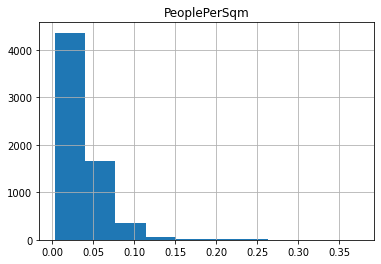

In [154]:
pathTUIK= '/content/drive/MyDrive/UBEM/IP1.1/Data Generation/OCC/OCC_TUIK_household - toSmooth.csv'

dfTUIK = pd.read_csv(pathTUIK)

dfTUIK.head()
dfTUIK.median()
dfTUIK.hist()

In [124]:
#@title zscore linear
def outlierLinFor(s):
    '''
    https://www.analyticsvidhya.com/blog/2021/06/power-of-interpolation-in-python-to-fill-missing-values/
    '''
    s = s.where(np.abs(stats.zscore(s)) < 1.5, np.nan)
    s = s.fillna(s.interpolate(method ='linear', limit_direction ='forward'))
    return s
    
outlierLinFor(dfTUIK).to_csv('LinearForward.csv')

In [163]:
#@title IQR Linear Forward
# IQR Method to remove outliers
df = dfTUIK
def outliers(s): 
    '''
    https://www.analyticsvidhya.com/blog/2021/06/power-of-interpolation-in-python-to-fill-missing-values/
    https://careerfoundry.com/en/blog/data-analytics/how-to-find-outliers/
    '''
    Q1, Q3 = np.percentile(s, [25 ,75])
    IQR = Q3-Q1
    #outliers = s[((s<( Q1-1.5*IQR)) | (s>(Q3+1.5*IQR)))]
    not_outliers = s[~((s<(Q1-1.5*IQR)) | (s>(Q3+1.5*IQR)))]
    not_outliers = not_outliers.fillna(not_outliers.interpolate(method ='linear', limit_direction ='forward'))
    return not_outliers

outliers(df).to_csv('LinearForwardIQR.csv')

In [166]:
#@title IQR Linear Backward
# IQR Method to remove outliers
df = dfTUIK
def outliers(s): 
    '''
    https://www.analyticsvidhya.com/blog/2021/06/power-of-interpolation-in-python-to-fill-missing-values/
    https://careerfoundry.com/en/blog/data-analytics/how-to-find-outliers/
    '''
    Q1, Q3 = np.percentile(s, [25 ,75])
    IQR = Q3-Q1
    #outliers = s[((s<( Q1-1.5*IQR)) | (s>(Q3+1.5*IQR)))]
    not_outliers = s[~((s<(Q1-1.5*IQR)) | (s>(Q3+1.5*IQR)))]
    not_outliers = not_outliers.fillna(not_outliers.interpolate(method ='linear', limit_direction ='backward'))
    return not_outliers

outliers(df).to_csv('LinearBackwardIQR.csv')

0.02927


array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f81c7c0cad0>]],
      dtype=object)

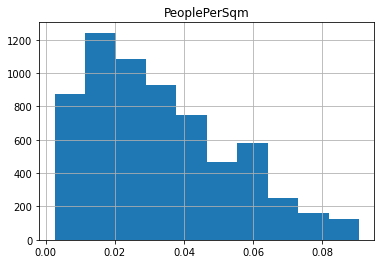

In [57]:
#@title iqrBound
def iqrBound(x):
    '''
    https://stackoverflow.com/questions/68698797/interquartile-rules-to-replace-outliers-in-python
    '''
    IQR = np.diff(x.quantile([0.25,0.75]))[0]
    S = 1.5*IQR
    x[x < Q1 - S] = Q1 - S
    x[x > Q3 + S] = Q1 + S
    return x

dfTUIK = dfTUIK.apply(iqrBound)
dfTUIK.hist()
#dfTUIK.count()
#dfTUIK.to_csv('boundaries.csv')

array([[<matplotlib.axes._subplots.AxesSubplot object at 0x7f81c7936c10>]],
      dtype=object)

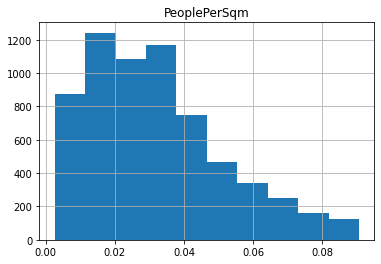

In [60]:
#@title iqrMedian
def iqrMedian(x):
    '''
    https://stackoverflow.com/questions/68698797/interquartile-rules-to-replace-outliers-in-python
    '''
    median = x.median()
    IQR = np.diff(x.quantile([0.25,0.75]))[0]
    S = 1.5*IQR
    x[x < Q1 - S] = median
    x[x > Q3 + S] = median
    return x

dfTUIK = dfTUIK.apply(iqrMedian)
dfTUIK.hist()
#dfTUIK.count()
#dfTUIK.to_csv('boundaries.csv')